In [1]:
#setting up the notebook
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

In [2]:
#reading the csv file
df= pd.read_csv('C:/Users/Lenovo/OneDrive/Desktop/BinX training/Project/data/medicaldataset.csv')

In [3]:
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


First i will do Kmeans for this datset for comparing

In [4]:
from sklearn.preprocessing import StandardScaler

X=df.drop('Result', axis=1)
scalar=StandardScaler()
X_scaled =scalar.fit_transform(X)

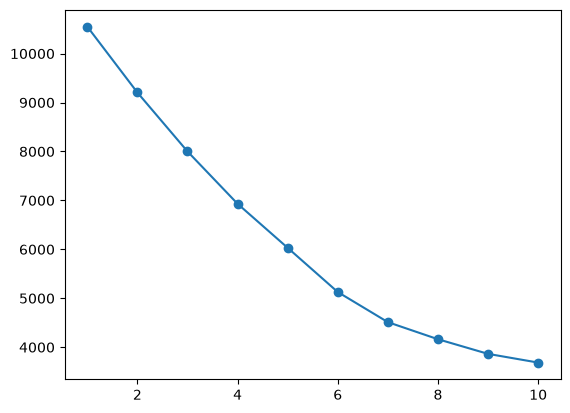

In [5]:
# finding the best k
from sklearn.cluster import KMeans
inertias = []

for k in range(1, 11):
 km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
 inertias.append(km.inertia_)
plt.plot(range(1, 11), inertias, marker="o") # look for the elbow

In [6]:
#silhouette score for 5 clusters

from sklearn.metrics import silhouette_score


km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)
print(km.cluster_centers_) 

score = silhouette_score(X_scaled, labels)
print('Score',score)

[[ 1.38353802e-01 -1.39199109e+00 -5.12808825e-02 -1.53699626e-02
   2.41826155e-02 -3.71441365e-02 -1.52874927e-01 -1.82971732e-01]
 [-5.27176189e-01 -6.88528927e-01  2.00087092e+01  5.29602635e-01
   1.62032216e+00 -4.93595785e-01 -2.73254958e-01 -1.06363363e-02]
 [-7.98990265e-02  7.18395402e-01 -4.50155794e-02 -1.14800774e-03
  -2.11726052e-02  5.36779999e-03 -1.62216172e-01 -7.83972075e-02]
 [ 3.17393517e-01  7.61038608e-02  6.08719229e-02  2.51544936e-01
   1.45075351e-01 -1.25335011e-02 -2.16107349e-01  6.22710114e+00]
 [ 2.16511107e-02  1.23158186e-01 -5.86879593e-02  4.26868960e-03
  -2.83241611e-02  3.40396344e-01  5.26158767e+00 -4.83277662e-04]]
Score 0.23867401034829455


In [7]:
#silhouette score for 6 clusters

km2 = KMeans(n_clusters=6, random_state=42, n_init=10)
labels2 = km2.fit_predict(X_scaled)
print(km2.cluster_centers_) 

score = silhouette_score(X_scaled, labels2)
print('Score',score)

[[ 1.90152132e-01 -1.39199109e+00 -5.55719085e-02 -1.73508107e-01
  -1.28892811e-01 -4.30877231e-02 -1.49138774e-01 -1.84629091e-01]
 [-8.13611751e-02  7.18395402e-01 -4.74267937e-02 -5.60359787e-01
  -5.64437240e-01  2.50535566e-02 -1.56183130e-01 -1.05929341e-01]
 [ 2.16511107e-02  1.23158186e-01 -5.86879593e-02  4.26868960e-03
  -2.83241611e-02  3.40396344e-01  5.26158767e+00 -4.83277662e-04]
 [-5.27176189e-01 -6.88528927e-01  2.00087092e+01  5.29602635e-01
   1.62032216e+00 -4.93595785e-01 -2.73254958e-01 -1.06363363e-02]
 [ 3.69110735e-01  4.69087907e-02  5.77702585e-02  1.91907084e-01
   4.88574773e-02  1.76274469e-02 -2.12155208e-01  6.35698356e+00]
 [-1.19233086e-01  5.22649409e-01 -3.65688411e-02  1.01556535e+00
   9.73610323e-01 -2.29829634e-02 -1.75028117e-01 -3.52561754e-02]]
Score 0.22525294797991846


5 clusters is better with 0.238 silhouette score 

Text(0.5, 1.0, 'Kmeans Clusters')

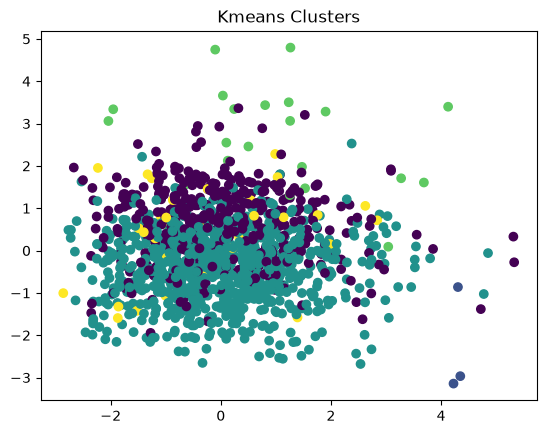

In [8]:
# making 2D df to plot
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)              

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title('Kmeans Clusters')

In [9]:
np.unique(labels, return_counts=True)

(array([0, 1, 2, 3, 4], dtype=int32), array([429,   3, 825,  23,  39]))

Model 2 : DBSCAN

In [10]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=2, min_samples=12)
labels2 = db.fit_predict(X_scaled)
# label -1 marks noise / outlier points

score = silhouette_score(X_scaled, labels2)
score

0.2113474099588734

In [11]:
df['cluster']=labels2
print(df['cluster'].value_counts())
n_clusters_db = df['cluster'].nunique() - (1)
print("number of clusters",  n_clusters_db)

cluster
 0    823
 1    421
-1     75
Name: count, dtype: int64
number of clusters 2


Text(0.5, 1.0, 'DBSCAN Clusters')

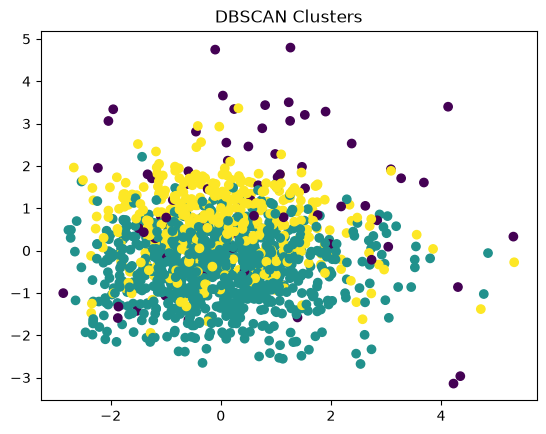

In [12]:
# making 2D df to plot

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)             

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels2)
plt.title('DBSCAN Clusters')

Model 3 :Hierarchical Clustering

0.21403245820716194

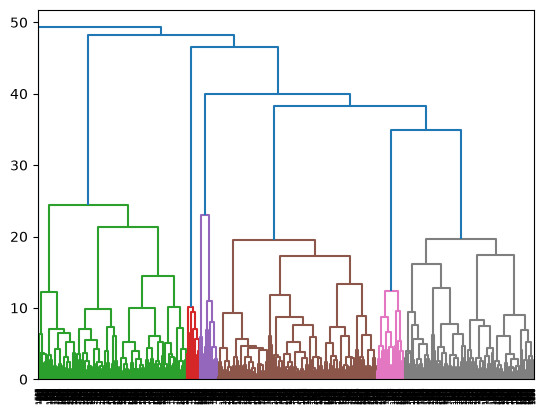

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(X_scaled, method="ward")
dendrogram(Z)   

hc_labels = fcluster(Z, t=5, criterion="maxclust")  
score = silhouette_score(X_scaled, hc_labels)
score

Text(0.5, 1.0, 'Hierarchical Clusters')

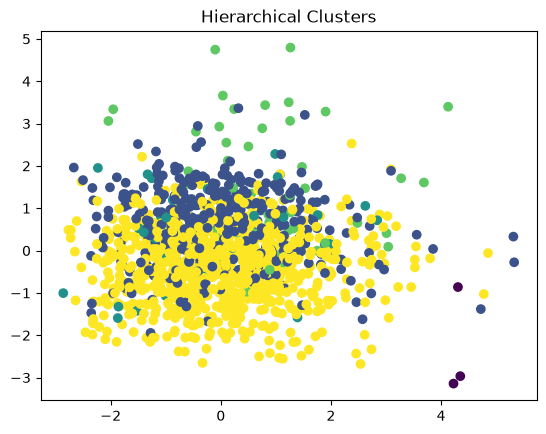

In [14]:
# making 2D df to plot

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)              

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=hc_labels, cmap='viridis')
plt.title('Hierarchical Clusters')

 Which Method Fits Best

| Method       | Clusters | Noise | Silhouette |
|--------------|----------|-------|------------|
| K-Means      | 5        | 0     | 0.238      |
| DBSCAN       | 2        | 75    | 0.211      |
| Hierarchical | 5        | 0     | 0.214     |

K-Means gave the most reasonable result for this dataset. Its silhouette
score (0.238) was honest and not inflated by an uneven cluster split.

DBSCAN found 2 clusters and marked 75 points as noise/outliers — useful
for spotting unusual cases, but its score was close to K-Means, not better.

Hierarchical's score (0.214) is also close to both scores — cutting the tree at 
5 clusters.

this dataset doesn't form strong, well-separated natural
clusters (all fair scores sit around 0.2–0.25). K-Means is the most
reliable and interpretable choice here, but the data itself may not have
clean geometric groupings, even though it has a real clinical outcome
label.

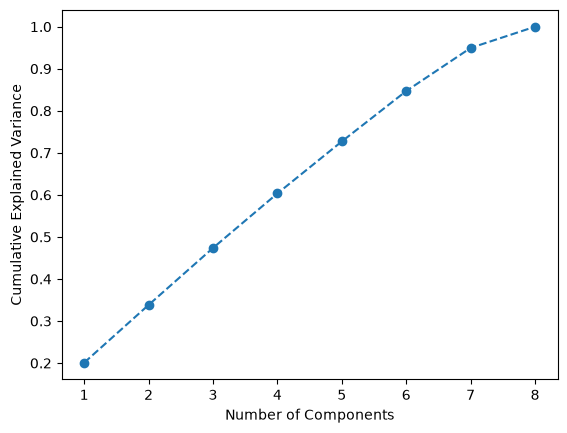

In [15]:
# PCA
pca_full = PCA(n_components=None)   
pca_full.fit(X_scaled)

cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

we cept 7 components to retain 95% of the data the varience and explains it

In [29]:
# score when 7 components kept
pca = PCA(n_components=7)
X_7d = pca.fit_transform(X_scaled)              

#from Day 2
km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_pca = km.fit_predict(X_7d)
score = silhouette_score(X_7d, labels_pca)
score


0.2336436916246169

PCA (7 components) gave a silhouette score of 0.233,  lower than the 0.238 achieved on the original 8 features.

Text(0.5, 1.0, 'Kmeans Clusters')

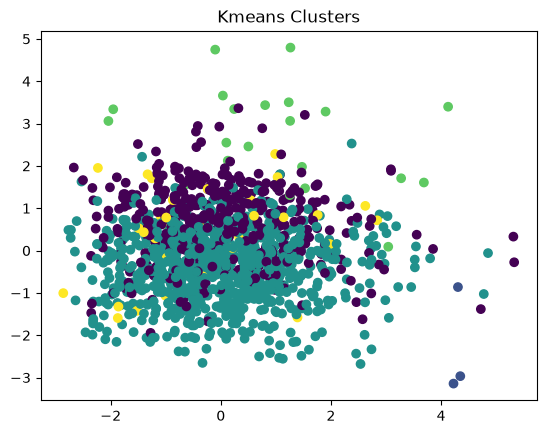

In [ ]:
# making 2D df to plot
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)              

#from Day 2
km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title('Kmeans Clusters')



Retained 95% of the core data and variance using the top 7 components.

By reducing the dataset to 2 dimensions, we gained the ability to visualize and inspect data distributions and clusters directly on a 2D plot—something impossible with high-dimensional data.

What was the cost:
Loss of 5% Variance: Discarding the remaining components resulted in a minor loss of detailed information (likely representing noise)
Loss of Direct Interpretability: The new components (PC1 and PC2) are no longer represent original features (like age or price), but rather mathematical combinations of multiple variables, making their literal meaning harder to interpret directly.

In [17]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Result', 'cluster'])
X_scaled = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

Text(0.5, 1.0, 't-SNE plot')

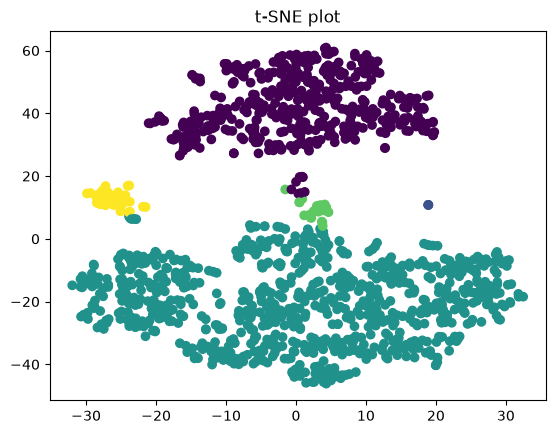

In [18]:
from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels)
plt.title("t-SNE plot")

PCA shows the overall spread of the data, but the heavy overlap makes some cluster boundaries difficult to distinguish. t-SNE reveals that the yellow points form a clearly separated local group, suggesting a meaningful cluster that was not obvious in PCA. Meanwhile, the purple and teal points remain relatively broad and internally connected, suggesting that they may not represent genuinely distinct groups.

In [19]:
#flagging the anomalies
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.05, random_state=42)
preds = iso.fit_predict(X_scaled)
# -1 = anomaly, 1 = normal
print(pd.Series(preds).value_counts())

 1    1253
-1      66
Name: count, dtype: int64


There are 66 anomalies flagged 

In [20]:
df['preds'] = preds  
anomalies= df[df['preds']==-1]
print(anomalies.head())


    Age  Gender  Heart rate  Systolic blood pressure  \
1    21       1          94                       98   
7    63       1          60                      214   
12   64       1          60                      199   
28   47       0          66                      134   
29   63       1          66                      135   

    Diastolic blood pressure  Blood sugar    CK-MB  Troponin    Result  \
1                         46        296.0    6.750     1.060  positive   
7                         82         87.0  300.000     2.370  positive   
12                        99         92.0    3.430     5.370  positive   
28                        57        279.0  300.000     0.007  positive   
29                        55        166.0    0.493    10.000  negative   

    cluster  preds  
1         0     -1  
7        -1     -1  
12       -1     -1  
28       -1     -1  
29       -1     -1  


In [21]:
normal_avg = df[df['preds'] == 1].mean(numeric_only=True)
print(normal_avg)


Age                          55.970471
Gender                        0.666401
Heart rate                   76.646449
Systolic blood pressure     126.335196
Diastolic blood pressure     72.142059
Blood sugar                 144.560814
CK-MB                         9.623105
Troponin                      0.244874
cluster                       0.313647
preds                         1.000000
dtype: float64


In [22]:
point_1 = anomalies.iloc[0]
print(point_1)


Age                               21
Gender                             1
Heart rate                        94
Systolic blood pressure           98
Diastolic blood pressure          46
Blood sugar                    296.0
CK-MB                           6.75
Troponin                        1.06
Result                      positive
cluster                            0
preds                             -1
Name: 1, dtype: object


In [23]:
point_2 = anomalies.iloc[1]
print(point_2)

Age                               63
Gender                             1
Heart rate                        60
Systolic blood pressure          214
Diastolic blood pressure          82
Blood sugar                     87.0
CK-MB                          300.0
Troponin                        2.37
Result                      positive
cluster                           -1
preds                             -1
Name: 7, dtype: object


### Anomaly Inspection

**Point 1 (index 1):**
- Age = 21 vs. normal average = 56 — unusually young for this dataset.
- Blood sugar = 296 vs. normal average = 144.6 — roughly double the typical value.
- Troponin = 1.06 vs. normal average = 0.24 — about 4x higher, a key marker of heart damage.
- Diastolic BP = 46 vs. normal average = 72.1 — notably low.
- Hypothesis: This point was flagged mainly because it's a rare combination — 
  a young patient with abnormally high troponin and blood sugar and low blood 
  pressure.

**Point 2 (index 7):**
- CK-MB = 300 vs. normal average = 9.6 — about 31x higher, an extreme spike.
- Troponin = 2.37 vs. normal average = 0.24 — nearly 10x higher.
- Systolic BP = 214 vs. normal average = 126.3 — far above typical range 
  (hypertensive crisis territory).
- Hypothesis: Unlike Point 1, this point doesn't need a rare combination to 
  stand out — CK-MB and troponin are both extreme outliers on their own. 
  These are classic biomarkers of a severe cardiac event (e.g., heart 
  attack), so this point was likely isolated almost immediately since a 
  single random split on CK-MB or troponin would separate it from the rest 
  of the dense "normal" population.


In [24]:
anomalies['Result'].value_counts()

Result
positive    63
negative     3
Name: count, dtype: int64